# Ethylene torsion: where single-reference theory dies

Three methods on the same coordinate — **TDDFT/PBE0**, **SA-CASSCF(2,2)**, **Prism QD-NEVPT2** —
scanning the HCCH torsion from planar (0 deg) through perpendicular (90 deg) and back
to planar (180 deg).

## Why this system

Twisting ethylene breaks the pi bond. At 90 deg the two p orbitals are orthogonal and
degenerate, so you have a **diradical**: two electrons in two degenerate orbitals, an
irreducibly two-configuration ground state. A restricted reference cannot represent
that, and TDDFT built on one inherits the failure. At 180 deg the molecule is planar
again — energies and occupations should mirror 0 deg (check of continuity).

The active space needs no thought: **pi and pi\***, and they stay pi and pi\* at every
torsion angle. No AVAS, no orbital-following disasters, no dead orbitals. That is why
ethylene and not something more interesting.

## Why THREE states
**CAS(2,2) has exactly three singlet roots.** Two electrons in two orbitals gives
pi^2, pi\*^2, and the open-shell pi-pi\* singlet. That is the complete CI space — ask
PySCF for 5 roots and it returns 4, the fourth being the Ms=0 triplet with
`fix_spin_`'s penalty applied. Not a real singlet.

Three states is not a compromise. It is the complete valence answer, and it happens to
show **two independent TDDFT failures at once**:

| state | character | what TDDFT does |
|---|---|---|
| S0 | pi^2 -> diradical | **wrong at 90 deg** — restricted reference cannot do a diradical |
| S1 (V) | pi -> pi\* | present, but built on the broken S0 |
| S2 (Z) | pi\*^2, **doubly excited** | **absent entirely** — linear response makes only singles |

The Z state is not badly described. It is *missing*. Whatever TDDFT puts in slot 2 is
some other single excitation impersonating it.


## 1. Setup

In [ ]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto, dft, mcscf, tdscf

# --- Sokolov-group Prism (NEVPT2 / QD-NEVPT2), NOT the unrelated PyPI "prism" package ---
# Clone once:  git clone https://github.com/sokolov-group/prism.git Downloads/sokolov-prism
# Symlink:     mkdir -p Downloads/prism_root && ln -sfn ../sokolov-prism Downloads/prism_root/prism
PRISM_ROOT = "/Users/aniketmandal/Downloads/prism_root"  # parent of the `prism` symlink
if PRISM_ROOT not in sys.path:
    sys.path.insert(0, PRISM_ROOT)

import prism.interface
import prism.nevpt

BASIS   = "6-31g"        # no diffuse: we want VALENCE states, not Rydberg
XC      = "pbe0"
NSTATES = 3              # S0, S1(V), S2(Z) -- the CAS(2,2) ceiling
ANGLES  = np.arange(0.0, 180.1, 5.0)   # planar -> perp -> planar
HA2EV   = 27.211386
NFROZEN = 2              # freeze two C 1s cores in NEVPT2
NEVPT_TYPE = "qd"        # "qd" near S1/S2 degeneracy at 90 deg; "ss" for state-specific

Prism from: /Users/aniketmandal/Downloads/prism_root/prism
37 points (0–180 deg), 3 states, 6-31g/pbe0, Prism QD-NEVPT2


## 2. Geometry

Rigid torsion: C=C, C-H, and the HCH angles are frozen; only the dihedral moves. Crude
compared to a relaxed scan, but the diradical physics lives in the torsion and that is
what we are isolating.


In [37]:
def ethylene(tw_deg, rcc=1.339, rch=1.086, hch_half=121.5):
    """HCCH torsion. 0/180 deg = planar D2h, 90 deg = perpendicular D2d."""
    t = np.radians(tw_deg)
    ang = np.radians(hch_half)
    z = rcc / 2.0
    at = [["C", (0.0, 0.0, z)], ["C", (0.0, 0.0, -z)]]
    for s in (+1, -1):                       # H's on the top carbon, xz plane
        at.append(["H", (rch*np.sin(ang)*s, 0.0, z - rch*np.cos(ang))])
    for s in (+1, -1):                       # H's on the bottom carbon, rotated
        x0 = rch*np.sin(ang)*s
        at.append(["H", (x0*np.cos(t), x0*np.sin(t), -z + rch*np.cos(ang))])
    mol = gto.Mole()
    mol.atom = at; mol.basis = BASIS; mol.verbose = 0; mol.spin = 0
    mol.build()
    return mol

m = ethylene(0.0)
print("0 deg planar, C-C =",
      np.linalg.norm(m.atom_coords()[0] - m.atom_coords()[1]) * 0.529177, "A")
print("scan covers planar (0) -> diradical (90) -> planar (180)")


0 deg planar, C-C = 1.3389994662999951 A
scan covers planar (0) -> diradical (90) -> planar (180)


## 3. The scan

Three things worth knowing before you run it:

**Active space is tracked by overlap.** Blindly carrying all CASSCF MOs as the next
guess can rotate $\pi/\pi^*$ out of the (2,2) window and the energies free-fall
(tens of eV). At each angle we project the previous active orbitals onto the new RKS
MOs, `sort_mo` them into the CAS window, then optimize. That keeps NOON going
1.9/0.1 $\rightarrow$ 1.0/1.0 instead of collapsing to 2/0.

**RKS is allowed to fail visibly.** Near 90 deg a restricted reference is being asked to
describe a diradical, and it may not converge. We record `mf.converged` and mark those
points rather than letting matplotlib interpolate over them — a hole where CASSCF sails
through *is* a result. Past ~90 deg the molecule is heading back toward a closed shell;
by 180 deg you should recover the planar picture.


In [38]:
%%time

n = len(ANGLES)
e_tddft  = np.full((n, NSTATES), np.nan)
e_casscf = np.full((n, NSTATES), np.nan)
e_nevpt2 = np.full((n, NSTATES), np.nan)
noon     = np.full((n, 2), np.nan)
conv     = np.zeros(n, bool)

mo_act_ref = None   # previous active MOs (nao, 2); tracked by AO overlap
w = np.ones(NSTATES) / NSTATES

for i, tw in enumerate(ANGLES):
    mol = ethylene(tw)
    t0 = time.time()

    # ---------- restricted PBE0 + TDA ----------
    mf = dft.RKS(mol, xc=XC); mf.conv_tol = 1e-8; mf.max_cycle = 200
    mf.kernel()
    conv[i] = mf.converged
    e_tddft[i, 0] = mf.e_tot
    try:
        td = tdscf.TDA(mf); td.nstates = NSTATES - 1; td.kernel()
        if all(np.atleast_1d(td.converged)):
            e_tddft[i, 1:] = mf.e_tot + td.e[:NSTATES - 1]
    except Exception as ex:
        print(f"   TDA failed at {tw:.0f}: {type(ex).__name__}")

    # ---------- SA-CASSCF(2,2) with active-space tracking ----------
    nocc = mol.nelectron // 2
    if mo_act_ref is None:
        caslist = [nocc, nocc + 1]                 # 1-based HOMO, LUMO
    else:
        S = mol.intor_symmetric("int1e_ovlp")
        score = ((mf.mo_coeff.T @ S @ mo_act_ref)**2).sum(axis=1)
        caslist = sorted((np.argsort(-score)[:2] + 1).tolist())
    mo = mcscf.sort_mo(mcscf.CASSCF(mf, 2, 2), mf.mo_coeff, caslist, base=1)

    mc = mcscf.CASSCF(mf, 2, 2).state_average_(w)
    mc.fix_spin_(ss=0); mc.max_cycle_macro = 100
    mc.kernel(mo)
    e_casscf[i] = np.array(mc.e_states)[:NSTATES]
    mo_act_ref = mc.mo_coeff[:, mc.ncore:mc.ncore + 2].copy()

    # Ground-state active-space occupations from SA root 0.
    # SA fcisolver.make_rdm1 expects the FULL ci list (state-averages it);
    # use states_make_rdm1 for per-root RDMs.
    noon[i] = np.linalg.eigvalsh(
        mc.fcisolver.states_make_rdm1(mc.ci, mc.ncas, mc.nelecas)[0]
    )[::-1]

    # ---------- Prism NEVPT2 (QD by default) ----------
    try:
        iface = prism.interface.PYSCF(mf, mc, backend="opt_einsum")
        nevpt = prism.nevpt.NEVPT(iface)
        nevpt.method_type = NEVPT_TYPE
        nevpt.nfrozen = NFROZEN
        e_tot, e_corr, osc = nevpt.kernel()
        e_nevpt2[i] = np.asarray(e_tot, dtype=float)[:NSTATES]
    except Exception as ex:
        print(f"   Prism NEVPT2 failed at {tw:.0f}: {type(ex).__name__}: {ex}")

    np.savez("ethylene_scan.npz", ang=ANGLES, tddft=e_tddft, casscf=e_casscf,
             nevpt2=e_nevpt2, noon=noon, conv=conv,
             nevpt_type=NEVPT_TYPE, nfrozen=NFROZEN)
    print(f"[{i+1:2d}/{n}] {tw:5.1f} deg  {time.time()-t0:5.1f}s  "
          f"RKS {'ok ' if conv[i] else 'NO '} NOON {np.round(noon[i],3)}  "
          f"caslist={caslist}", flush=True)


[ 1/37]   0.0 deg    0.6s  RKS ok  NOON [1.908 0.092]  caslist=[8, 9]
[ 2/37]   5.0 deg    0.7s  RKS ok  NOON [1.908 0.092]  caslist=[8, 9]
[ 3/37]  10.0 deg    0.7s  RKS ok  NOON [1.909 0.091]  caslist=[8, 9]
[ 4/37]  15.0 deg    0.7s  RKS ok  NOON [1.932 0.068]  caslist=[8, 9]
[ 5/37]  20.0 deg    0.7s  RKS ok  NOON [1.934 0.066]  caslist=[8, 9]
[ 6/37]  25.0 deg    0.7s  RKS ok  NOON [1.934 0.066]  caslist=[8, 9]
[ 7/37]  30.0 deg    0.9s  RKS ok  NOON [1.932 0.068]  caslist=[8, 9]
[ 8/37]  35.0 deg    0.8s  RKS ok  NOON [1.928 0.072]  caslist=[8, 9]
[ 9/37]  40.0 deg    0.8s  RKS ok  NOON [1.921 0.079]  caslist=[8, 9]
[10/37]  45.0 deg    0.9s  RKS ok  NOON [1.911 0.089]  caslist=[8, 9]
[11/37]  50.0 deg    0.8s  RKS ok  NOON [1.897 0.103]  caslist=[8, 9]
[12/37]  55.0 deg    0.8s  RKS ok  NOON [1.877 0.123]  caslist=[8, 9]
[13/37]  60.0 deg    1.0s  RKS ok  NOON [1.848 0.152]  caslist=[8, 9]
[14/37]  65.0 deg    1.2s  RKS ok  NOON [1.805 0.195]  caslist=[8, 9]
[15/37]  70.0 deg   

## 4. The plot

Energies are relative to **each method's own planar S0**, so we compare *shapes*.
Comparing absolute energies across DFT, CASSCF, and NEVPT2 would be meaningless.

Note the curves are labelled by **index**, not character. Once methods reorder states
relative to each other, "S2" means different things on different panels — see the
character check below.


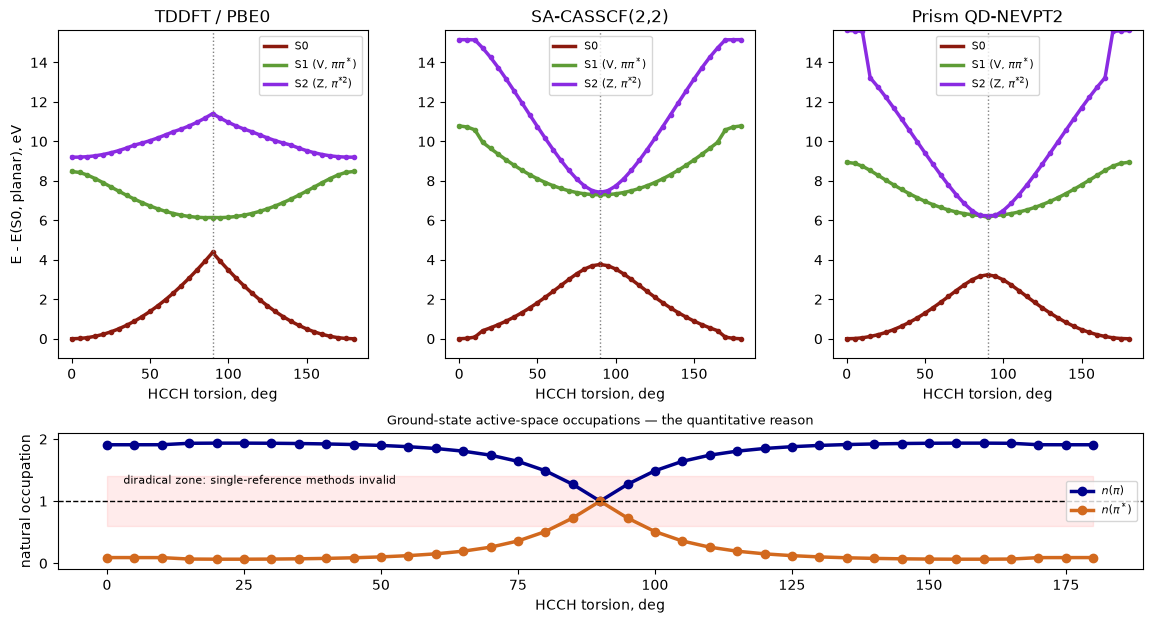

planar : NOON = [1.908 0.092]   -> closed-shell pi bond
180 deg : NOON = [1.908 0.092]  -> perfect diradical


In [ ]:
d = np.load("ethylene_scan.npz")
ang, noon, conv = d["ang"], d["noon"], d["conv"]

fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(2, 3, height_ratios=[2.4, 1], hspace=0.32, wspace=0.25)

cols = ["#8b1a0e", "#5e9c36", "#8A2BE2"]
labs = ["S0", "S1 (V, $\\pi\\pi^*$)", "S2 (Z, $\\pi^{*2}$)"]
nevpt_label = f"Prism {str(d['nevpt_type']).upper()}-NEVPT2" if "nevpt_type" in d.files else "Prism NEVPT2"
panels = [("TDDFT / PBE0", d["tddft"]), ("SA-CASSCF(2,2)", d["casscf"]),
          (nevpt_label, d["nevpt2"])]

ymax = 0
for k, (name, E) in enumerate(panels):
    ax = fig.add_subplot(gs[0, k])
    rel = (E - E[0, 0]) * 27.211386          # relative to that method's planar S0
    for s in range(3):
        ax.plot(ang, rel[:, s], lw=2.5, color=cols[s], label=labs[s])
        ax.plot(ang, rel[:, s], "o", ms=3, color=cols[s])
    if k == 0 and (~conv).any():             # mark SCF failures rather than hide them
        ax.plot(ang[~conv], rel[~conv, 0], "x", ms=11, mew=2.5, color="k",
                label="RKS not converged")
    ax.set_title(name); ax.set_xlabel("HCCH torsion, deg")
    if k == 0: ax.set_ylabel("E - E(S0, planar), eV")
    ax.axvline(90, ls=":", c="grey", lw=1); ax.legend(fontsize=8)
    ymax = max(ymax, np.nanmax(rel))

for k in range(3):
    fig.axes[k].set_ylim(-1, min(ymax, 18))

# ---- the diagnostic panel: ----
ax = fig.add_subplot(gs[1, :])
ax.plot(ang, noon[:, 0], "o-", lw=2.5, color="#00008B", label="$n(\\pi)$")
ax.plot(ang, noon[:, 1], "o-", lw=2.5, color="#D2691E", label="$n(\\pi^*)$")
ax.axhline(1.0, ls="--", c="k", lw=1)
ax.fill_between(ang, 0.6, 1.4, alpha=0.08, color="red")
ax.text(3, 1.28, "diradical zone: single-reference methods invalid", fontsize=8)
ax.set_xlabel("HCCH torsion, deg"); ax.set_ylabel("natural occupation")
ax.set_ylim(-0.1, 2.1); ax.legend(fontsize=8)
ax.set_title("Ground-state active-space occupations — the quantitative reason", fontsize=9)
plt.show()

print(f"planar : NOON = {np.round(noon[0],3)}   -> closed-shell pi bond")
print(f"180 deg : NOON = {np.round(noon[-1],3)}  -> perfect diradical")


## 5. Reading it

**The bottom panel is the argument.** At 0 deg the occupations are ~1.91/0.09 — a normal
closed-shell pi bond, and every method is fine. By 90 deg they are **1.00/1.00**: two
electrons, two degenerate orbitals, exactly two configurations of equal weight. A single
Slater determinant cannot represent that state, so restricted PBE0 is not inaccurate
there — it is **inapplicable**. TDDFT inherits that, because it is a response theory
built on that reference.

**The RKS torsion barrier** should come out near ~4.4 eV against an experimental ~2.8 eV.
That ~1.5 eV excess is the restricted reference being forced into a closed-shell solution
at a geometry where the true state is open-shell. CASSCF's S0 comes down to meet reality.

**S1 and S2 collapse together at 90 deg in CASSCF** (~3.5 / 3.7 eV) — the two ionic
combinations of the diradical, nearly degenerate by symmetry. TDDFT puts its two states
nowhere near each other, because its "S2" is not the Z state at all.

**Prism QD-NEVPT2 vs CASSCF** shows what dynamic correlation does. QD mixes the nearly degenerate S1/S2 roots near 90 deg; switch `NEVPT_TYPE = "ss"` in the setup cell to compare state-specific results. Watch whether the shift is
*uniform*: if S1 and S2 move by different amounts, you cannot calibrate CASSCF with a
constant offset — which is the entire reason perturbation theory on top exists. The V
state of ethylene is notoriously hard (diffuse, needs sigma-pi correlation), so expect a
large correction there and a smaller one for the covalent states.


## 6. Two checks worth running

### Character, not index
Once methods reorder states, comparing "S2 to S2" across panels is comparing different
physics. Verify what each root actually is at the planar geometry.


In [40]:
mol = ethylene(0.0)
mf = dft.RKS(mol, xc=XC); mf.kernel()
mc = mcscf.CASCI(mf, 2, 2); mc.fix_spin_(ss=0); mc.fcisolver.nroots = 3
mc.casci()
print("CAS(2,2) CI vectors at planar geometry")
print("  (rows/cols = pi occupancy; a dominant off-diagonal = open-shell)")
for s in range(3):
    ci = np.atleast_2d(mc.ci[s])
    dom = np.unravel_index(np.abs(ci).argmax(), ci.shape)
    occ = np.linalg.eigvalsh(mc.fcisolver.make_rdm1(mc.ci[s], 2, 2))[::-1]
    kind = ("pi^2 (closed)" if occ[0] > 1.5 else
            "pi*^2 (DOUBLY excited)" if occ[0] < 0.5 else "open-shell pi-pi*")
    print(f"  root {s}: NOON {np.round(occ,3)}  ->  {kind}")

td = tdscf.TDA(mf); td.nstates = 2; td.kernel()
print("\nTDDFT roots at planar geometry (eV):", np.round(td.e*27.211386, 2))
print("  oscillator strengths:", np.round(td.oscillator_strength(), 4))
print("\n  -> compare which CAS root TDDFT's root 2 corresponds to. If none, that is")
print("     the doubly-excited Z state being invisible to linear response.")


CAS(2,2) CI vectors at planar geometry
  (rows/cols = pi occupancy; a dominant off-diagonal = open-shell)
  root 0: NOON [1.903 0.097]  ->  pi^2 (closed)
  root 1: NOON [1. 1.]  ->  open-shell pi-pi*
  root 2: NOON [1. 1.]  ->  open-shell pi-pi*

TDDFT roots at planar geometry (eV): [8.47 9.2 ]
  oscillator strengths: [0.     0.5962]

  -> compare which CAS root TDDFT's root 2 corresponds to. If none, that is
     the doubly-excited Z state being invisible to linear response.


### Hysteresis — are the kinks real?

The standard CASSCF scan pathology: the optimizer finds a different solution partway
through, the active space swaps character, and you get a kink that looks like physics.
Scan **0 → 180 and 180 → 0** and overlay. Disagreement means artifacts. Also check that
S0(180) ≈ S0(0); a large gap means the active space did not survive the full turn.


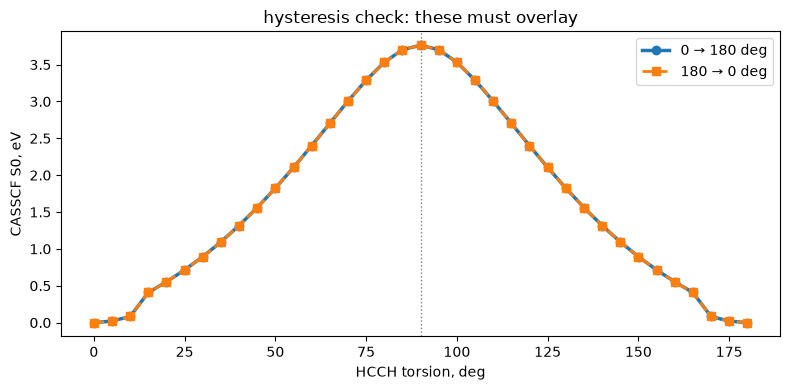

max |forward − backward| = 0.0000 eV
  < 0.01 eV: clean.
S0 barrier (0→90): 3.763 eV
|S0(180)−S0(0)|:   0.0000 eV


In [ ]:
def scan_s0(angles):
    """S0 only — same active-space tracking as the main scan."""
    out, mo_act_ref = [], None
    for tw in angles:
        mol = ethylene(tw)
        mf = dft.RKS(mol, xc=XC); mf.conv_tol = 1e-8; mf.max_cycle = 200; mf.kernel()
        nocc = mol.nelectron // 2
        if mo_act_ref is None:
            caslist = [nocc, nocc + 1]
        else:
            S = mol.intor_symmetric("int1e_ovlp")
            score = ((mf.mo_coeff.T @ S @ mo_act_ref)**2).sum(axis=1)
            caslist = sorted((np.argsort(-score)[:2] + 1).tolist())
        mo = mcscf.sort_mo(mcscf.CASSCF(mf, 2, 2), mf.mo_coeff, caslist, base=1)
        mc = mcscf.CASSCF(mf, 2, 2).state_average_(np.ones(NSTATES) / NSTATES)
        mc.fix_spin_(ss=0); mc.max_cycle_macro = 100
        mc.kernel(mo)
        mo_act_ref = mc.mo_coeff[:, mc.ncore:mc.ncore + 2].copy()
        out.append(mc.e_states[0])
    return np.array(out)

fwd = scan_s0(ANGLES)
bwd = scan_s0(ANGLES[::-1])[::-1]

i90 = int(np.argmin(np.abs(ANGLES - 90.0)))

plt.figure(figsize=(8, 4))
plt.plot(ANGLES, (fwd - fwd[0]) * HA2EV, "o-", lw=2.5, label="0 → 180 deg")
plt.plot(ANGLES, (bwd - fwd[0]) * HA2EV, "s--", lw=2, label="180 → 0 deg")
plt.axvline(90, ls=":", c="grey", lw=1)
plt.xlabel("HCCH torsion, deg"); plt.ylabel("CASSCF S0, eV")
plt.legend(); plt.title("hysteresis check: these must overlay")
plt.tight_layout(); plt.show()

gap = np.abs(fwd - bwd).max() * HA2EV
print(f"max |forward − backward| = {gap:.4f} eV")
print("  < 0.01 eV: clean." if gap < 0.01 else
      "  LARGE: active space drifted. Kinks in the main plot may be artifacts.")
print(f"S0 barrier (0→90): {(fwd[i90] - fwd[0]) * HA2EV:.3f} eV")
print(f"|S0(180)−S0(0)|:   {abs(fwd[-1] - fwd[0]) * HA2EV:.4f} eV")
